# Sanity check: does the differentiable fine-tuning work?

Minimal synthetic datasets and formulas where the "correct" threshold / time-interval is known by construction, so we can directly check whether `stlrocket.tuning.finetune_formula` moves parameters in the right direction and improves true (hard-threshold) F1 -- not just the soft surrogate it actually optimizes.

Three toys:
1. Atom threshold only (no temporal operator).
2. `Eventually[a,b]` window position.
3. `Globally[a,b]` window + threshold jointly.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, for the local (non pip-installed) stlrocket package

import numpy as np
import matplotlib.pyplot as plt
from torcheck.stl import Atom, Eventually, Globally

from stlrocket.tuning import finetune_formula
from stlrocket.evaluation import evaluate_global

np.random.seed(0)

## Toy 1: atom threshold only

Two classes, one variable, constant-ish signal: `hi` around `+5`, `lo` around `-5`. The true separating threshold is `0`. We start from a deliberately bad threshold (`-8`, so `x_0 >= -8` is trivially true for almost everyone) and check that fine-tuning moves it toward `0` and improves F1 for target class `hi`.

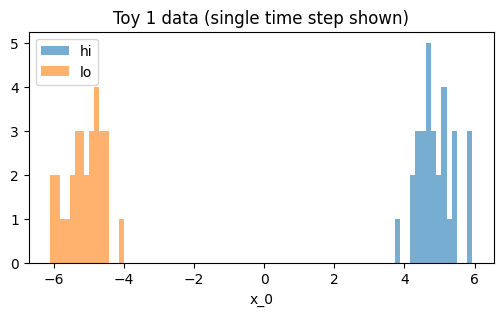

In [2]:
np.random.seed(0)
N, T = 60, 10
x_hi = 5 + 0.5 * np.random.randn(N // 2, 1, T)
x_lo = -5 + 0.5 * np.random.randn(N // 2, 1, T)
X1 = np.concatenate([x_hi, x_lo], axis=0).astype(np.float32)
y1 = np.array(["hi"] * (N // 2) + ["lo"] * (N // 2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(X1[y1 == "hi", 0, 0], bins=15, alpha=0.6, label="hi")
ax.hist(X1[y1 == "lo", 0, 0], bins=15, alpha=0.6, label="lo")
ax.set_xlabel("x_0"); ax.legend(); ax.set_title("Toy 1 data (single time step shown)")
plt.show()

In [3]:
phi1_bad = Atom(var_index=0, threshold=-8.0, lte=False)  # x_0 >= -8, trivially true

f1_before = evaluate_global({"hi": phi1_bad}, X1, y1)["hi"]["f1"]
phi1_tuned, _log1 = finetune_formula(
    phi1_bad, X1, y1, "hi", n_steps=300,
    # tau/beta only affect temporal (Globally/Eventually/Until) windows --
    # Toy 1 is a bare atom, so they're unused here; annealed anyway for
    # consistency with the other toys.
    tau_init=1.0, tau_final=0.1,
    beta_init=0.5, beta_final=0.05,
    sigmoid_temp_init=1.0, sigmoid_temp_final=0.05,
)
f1_after = evaluate_global({"hi": phi1_tuned}, X1, y1)["hi"]["f1"]

print(f"threshold: {phi1_bad.threshold} -> {phi1_tuned.threshold:.3f}   (true separator is ~0)")
print(f"F1:        {f1_before:.3f} -> {f1_after:.3f}")

threshold: -8.0 -> -2.489   (true separator is ~0)
F1:        0.667 -> 1.000


## Toy 2: `Eventually[a,b]` window position

Two classes with a 3-step spike (`x_0 += 5`) at different times: `early` at `t=3..5`, `late` at `t=12..14`. Baseline is near-zero noise. Target class is `early`; the true window is `[3,5]`.

We start from `F[12,14](x_0 >= 3)` -- the window for the *other* class's spike, so `F1` for `early` starts at `nan` (nobody satisfies it). This is a harder test than Toy 1: the window needs to move a long way with (initially) zero overlap with the correct interval.

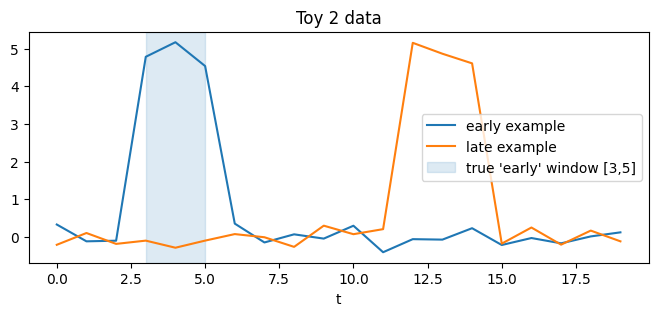

In [4]:
np.random.seed(1)
N, T = 60, 20

def make_spike_series(spike_start):
    x = 0.2 * np.random.randn(N // 2, 1, T)
    x[:, 0, spike_start:spike_start + 3] += 5.0
    return x

x_early = make_spike_series(3)
x_late = make_spike_series(12)
X2 = np.concatenate([x_early, x_late], axis=0).astype(np.float32)
y2 = np.array(["early"] * (N // 2) + ["late"] * (N // 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X2[0, 0], label="early example")
ax.plot(X2[N // 2, 0], label="late example")
ax.axvspan(3, 5, color="C0", alpha=0.15, label="true 'early' window [3,5]")
ax.set_xlabel("t"); ax.legend(); ax.set_title("Toy 2 data")
plt.show()

In [23]:
phi2_bad = Eventually(
    Atom(var_index=0, threshold=3.0, lte=False),
    unbound=False, right_unbound=False, left_time_bound=12, right_time_bound=14,
)

f1_before = evaluate_global({"early": phi2_bad}, X2, y2)["early"]["f1"]
phi2_tuned, _log2 = finetune_formula(
    phi2_bad, X2, y2, "early", n_steps=20000,
    tau_init=5.0, tau_final=0.01,
    beta_init=1.0, beta_final=0.01,
    sigmoid_temp_init=1.0, sigmoid_temp_final=0.01,
    lambda_width=1, min_width=1
)
f1_after = evaluate_global({"early": phi2_tuned}, X2, y2)["early"]["f1"]

print(f"window: [12,14] -> [{phi2_tuned.left_time_bound},{phi2_tuned.right_time_bound - 1}]   (true window is [3,5])")
print(f"threshold: 3.0 -> {phi2_tuned.child.threshold:.3f}")
print(f"F1: {f1_before} -> {f1_after:.3f}")


window: [12,14] -> [3,16]   (true window is [3,5])
threshold: 3.0 -> -0.666
F1: nan -> 0.667


## Toy 3: `Globally[a,b]` window + threshold jointly

`stable` never exceeds `~0` (small noise); `spiky` has one `+3` excursion at a random time in `[5,15]`. The true explanation for `stable` is "stays below ~1.5 throughout `[5,15]`" -- i.e. the *full* window `[5,15]` with threshold `~1.5`. We start from the correct window but a much-too-loose threshold (`5.0`, so `G[5,15](x_0 <= 5)` is trivially true for both classes) and check what fine-tuning does to *both* the threshold and the window simultaneously.

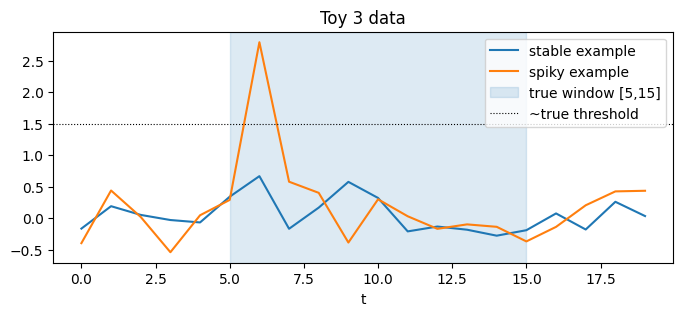

In [6]:
#np.random.seed(2)
N, T = 60, 20

x_stable = 0.3 * np.random.randn(N // 2, 1, T)
x_spiky = 0.3 * np.random.randn(N // 2, 1, T)
for i in range(N // 2):
    t = np.random.randint(5, 16)
    x_spiky[i, 0, t] += 3.0
X3 = np.concatenate([x_stable, x_spiky], axis=0).astype(np.float32)
y3 = np.array(["stable"] * (N // 2) + ["spiky"] * (N // 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X3[0, 0], label="stable example")
ax.plot(X3[N // 2, 0], label="spiky example")
ax.axvspan(5, 15, color="C0", alpha=0.15, label="true window [5,15]")
ax.axhline(1.5, color="black", linestyle=":", linewidth=0.8, label="~true threshold")
ax.set_xlabel("t"); ax.legend(); ax.set_title("Toy 3 data")
plt.show()

In [19]:
phi3_bad = Globally(
    Atom(var_index=0, threshold=1.0, lte=True),
    unbound=False, right_unbound=False, left_time_bound=5, right_time_bound=6,
)

f1_before = evaluate_global({"stable": phi3_bad}, X3, y3)["stable"]["f1"]
phi3_tuned, _log3 = finetune_formula(
    phi3_bad, X3, y3, "stable", n_steps=10000,
    tau_init=1.0, tau_final=0.01,
    beta_init=1.0, beta_final=0.01,
    sigmoid_temp_init=1.0, sigmoid_temp_final=0.1,
    lambda_width=1, min_width=1
)
f1_after = evaluate_global({"stable": phi3_tuned}, X3, y3)["stable"]["f1"]

print(f"threshold: 5.0 -> {phi3_tuned.child.threshold:.3f}   (true threshold is ~1.5)")
print(f"window: [5,6] -> [{phi3_tuned.left_time_bound},{phi3_tuned.right_time_bound - 1}]   (true window is [5,15])")
print(f"F1: {f1_before:.3f} -> {f1_after:.3f}")


threshold: 5.0 -> 1.709   (true threshold is ~1.5)
window: [5,6] -> [5,15]   (true window is [5,15])
F1: 0.690 -> 1.000
